In [1]:
import mygene
import pandas as pd

In [2]:
# Instantiate the query client
mg = mygene.MyGeneInfo()

In [3]:
loops_with_entrezid=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/loops_with_gene_info_genelevel.csv", sep=",")
loops_with_entrezid

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,388591
1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.034904,0.5110,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,22883
2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,0.010033,...,0.039089,0.5410,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,1889
3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,0.027536,...,0.053035,0.5062,0.0320,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,2048
4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,0.030242,...,0.044438,0.5421,0.0034,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,2048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,32165,chr7,51412500,51417500,chr7,55602500,55607500,gained,0.021059,0.011941,...,0.027326,0.3701,0.0042,0.406646,0.454487,0.610640,0.678323,0.047841,0.067683,1956
1161,32208,chr8,94812500,94817500,chr8,95022500,95027500,gained,0.012306,0.015876,...,0.028713,0.4527,0.0298,0.040931,0.090414,0.528279,0.409177,0.049483,-0.119102,9134
1162,32213,chr8,122735000,122740000,chr8,123060000,123065000,gained,0.005878,0.011803,...,0.043533,0.4314,0.0084,0.580906,0.531595,-0.156556,-0.213083,-0.049312,-0.056527,22882
1163,32230,chr9,33582500,33587500,chr9,38552500,38557500,gained,0.040927,0.032843,...,0.034770,0.4688,0.0044,-0.120256,-0.077855,0.011444,-0.040473,0.042401,-0.051918,7169


In [4]:
# Step 1: Expand multiple gene IDs
split_ids = loops_with_entrezid['gene_id'].dropna().astype(str).str.split(',')

# Step 2: Flatten and keep only numeric values
flat_ids = [i.strip() for sublist in split_ids for i in sublist if i.strip().isdigit()]
unique_entrez_ids = list(set(flat_ids))

# Step 3: Query MyGene.info
results = mg.querymany(unique_entrez_ids, scopes='entrezgene', fields='symbol', species='human')

# Step 4: Build mapping dictionary
entrez_to_symbol = {r['query']: r.get('symbol', None) for r in results}

# Step 5: Map gene symbols (handling multi-ID rows)
def map_ids_to_symbols(gene_id_str):
    if pd.isna(gene_id_str):
        return None
    ids = gene_id_str.split(',')
    symbols = [entrez_to_symbol.get(i.strip()) for i in ids if i.strip() in entrez_to_symbol]
    return ','.join(sorted(set(filter(None, symbols)))) if symbols else None

# Step 6: Apply to your DataFrame
loops_with_entrezid['gene_symbol'] = loops_with_entrezid['gene_id'].astype(str).apply(map_ids_to_symbols)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [5]:
loops_with_entrezid

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,388591,RNF207
1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.5110,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,22883,CLSTN1
2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,0.010033,...,0.5410,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,1889,ECE1
3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,0.027536,...,0.5062,0.0320,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,2048,EPHB2
4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,0.030242,...,0.5421,0.0034,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,2048,EPHB2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,32165,chr7,51412500,51417500,chr7,55602500,55607500,gained,0.021059,0.011941,...,0.3701,0.0042,0.406646,0.454487,0.610640,0.678323,0.047841,0.067683,1956,EGFR
1161,32208,chr8,94812500,94817500,chr8,95022500,95027500,gained,0.012306,0.015876,...,0.4527,0.0298,0.040931,0.090414,0.528279,0.409177,0.049483,-0.119102,9134,CCNE2
1162,32213,chr8,122735000,122740000,chr8,123060000,123065000,gained,0.005878,0.011803,...,0.4314,0.0084,0.580906,0.531595,-0.156556,-0.213083,-0.049312,-0.056527,22882,ZHX2
1163,32230,chr9,33582500,33587500,chr9,38552500,38557500,gained,0.040927,0.032843,...,0.4688,0.0044,-0.120256,-0.077855,0.011444,-0.040473,0.042401,-0.051918,7169,TPM2


In [6]:
loops_with_entrezid[200:600]

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol
200,4589,chr3,124762500,124767500,chr3,124902500,124907500,shared,0.054332,0.047478,...,0.4842,0.0832,-0.519056,-0.538427,-0.687634,-0.655404,-0.019371,0.032229,56667,MUC13
201,4591,chr3,124922500,124927500,chr3,125582500,125587500,shared,0.017113,0.011961,...,0.4044,0.0216,0.420719,0.511961,0.424292,0.413881,0.091242,-0.010410,56667,MUC13
202,4592,chr3,124925000,124930000,chr3,124985000,124990000,shared,0.023137,0.023416,...,0.4360,0.0148,0.424292,0.413881,0.710310,0.626747,-0.010410,-0.083563,56667,MUC13
203,4593,chr3,124925000,124930000,chr3,125440000,125445000,shared,0.008579,0.008408,...,0.4272,0.0028,0.481651,0.493746,0.642988,0.580571,0.012094,-0.062418,56667,MUC13
204,4714,chr3,156150000,156155000,chr3,157085000,157090000,shared,0.011267,0.010066,...,0.4447,0.0506,-0.001249,0.042743,-0.001292,-0.027420,0.043992,-0.026128,"339894,389170","LEKR1,LINC00880"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,16090,chr15,80855000,80860000,chr15,80950000,80955000,lost,0.017460,0.012835,...,0.4847,0.0266,0.699851,0.612543,0.641519,0.588672,-0.087308,-0.052847,57214,CEMIP
596,16108,chr15,98775000,98780000,chr15,98845000,98850000,lost,0.015100,0.012079,...,0.4491,0.0662,-0.293520,-0.226642,-0.733886,-0.780235,0.066878,-0.046349,3480,IGF1R
597,16115,chr16,2192500,2197500,chr16,2502500,2507500,lost,NaN,NaN,...,0.5671,0.1974,0.580721,0.576386,0.636063,0.570906,-0.004335,-0.065157,"1775,21","ABCA3,DNASE1L2"
598,16134,chr16,29702500,29707500,chr16,30022500,30027500,lost,0.020618,0.018544,...,0.5276,0.1244,0.809268,0.695337,0.753435,0.732419,-0.113931,-0.021016,26470,SEZ6L2


---

In [7]:
# Now let's join the log2fc

In [8]:
up=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt", sep="\t")
down=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt", sep="\t")
all=pd.concat([up, down])
all

,ensembl_id,ensembl,log2FC,hgnc_symbol
0,ENSG00000005339,ENSG00000005339.15,0.653104,CREBBP
1,ENSG00000010292,ENSG00000010292.13,0.711214,NCAPD2
2,ENSG00000011347,ENSG00000011347.10,0.696552,SYT7
3,ENSG00000013288,ENSG00000013288.9,0.703644,MAN2B2
4,ENSG00000026508,ENSG00000026508.21,0.749793,CD44
...,...,...,...,...
77,ENSG00000290076,ENSG00000290076.1,-0.690556,ENSG00000290076
78,ENSG00000290548,ENSG00000290548.2,-0.628500,ENSG00000290548
79,ENSG00000291100,ENSG00000291100.2,-0.647279,ENSG00000291100
80,ENSG00000291117,ENSG00000291117.2,-0.658197,ENSG00000291117


In [9]:
# Step 1: Create a mapping from gene symbol to log2FC
symbol_to_log2fc = dict(zip(all['hgnc_symbol'], all['log2FC']))

# Step 2: Function to handle multi-gene-symbol rows
def map_log2fc_multi(gene_str):
    if pd.isna(gene_str):
        return None
    symbols = [s.strip() for s in gene_str.split(',')]
    log2fcs = [round(symbol_to_log2fc[s], 3) for s in symbols if s in symbol_to_log2fc]
    return ','.join(map(str, log2fcs)) if log2fcs else None

# Step 3: Apply to your dataframe
loops_with_entrezid['gene_log2fc'] = loops_with_entrezid['gene_symbol'].apply(map_log2fc_multi)

In [10]:
loops_with_entrezid

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,388591,RNF207,-0.733
1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,22883,CLSTN1,0.624
2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,0.010033,...,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,1889,ECE1,0.743
3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,0.027536,...,0.0320,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,2048,EPHB2,0.881
4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,0.030242,...,0.0034,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,2048,EPHB2,0.881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,32165,chr7,51412500,51417500,chr7,55602500,55607500,gained,0.021059,0.011941,...,0.0042,0.406646,0.454487,0.610640,0.678323,0.047841,0.067683,1956,EGFR,0.761
1161,32208,chr8,94812500,94817500,chr8,95022500,95027500,gained,0.012306,0.015876,...,0.0298,0.040931,0.090414,0.528279,0.409177,0.049483,-0.119102,9134,CCNE2,-0.729
1162,32213,chr8,122735000,122740000,chr8,123060000,123065000,gained,0.005878,0.011803,...,0.0084,0.580906,0.531595,-0.156556,-0.213083,-0.049312,-0.056527,22882,ZHX2,0.754
1163,32230,chr9,33582500,33587500,chr9,38552500,38557500,gained,0.040927,0.032843,...,0.0044,-0.120256,-0.077855,0.011444,-0.040473,0.042401,-0.051918,7169,TPM2,-1.545


In [11]:
#loops_with_entrezid[loops_with_entrezid["status"]=="gained"] # 469 ## gained_loops
# Ensure the column is numeric
loops_with_entrezid["gene_log2fc"] = pd.to_numeric(loops_with_entrezid["gene_log2fc"], errors='coerce')

# Then apply your filter
filtered_loops_gained = loops_with_entrezid[
    (loops_with_entrezid["status"] == "gained") &
    (loops_with_entrezid["gene_log2fc"] >= 0)
]
filtered_loops_gained # 389
## Out of 469 gained loops 385 had positive log2fc

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
696,19054,chr1,9780000,9785000,chr1,9865000,9870000,gained,0.049133,0.038743,...,0.0990,-0.066175,-0.070481,0.001674,-0.044828,-0.004306,-0.046502,22883,CLSTN1,0.624
697,19101,chr1,21225000,21230000,chr1,21575000,21580000,gained,0.015427,0.010033,...,0.0262,0.646761,0.642833,0.573081,0.529001,-0.003928,-0.044081,1889,ECE1,0.743
698,19102,chr1,21232500,21237500,chr1,21352500,21357500,gained,0.028127,0.027645,...,0.0458,0.842165,0.751483,0.724116,0.721632,-0.090682,-0.002484,1889,ECE1,0.743
699,19106,chr1,22422500,22427500,chr1,22932500,22937500,gained,0.007626,0.008484,...,0.0258,0.623827,0.679978,0.644298,0.584921,0.056151,-0.059377,2048,EPHB2,0.881
700,19107,chr1,22662500,22667500,chr1,22912500,22917500,gained,0.014094,0.011554,...,0.0574,0.718372,0.620821,0.648067,0.563399,-0.097552,-0.084668,2048,EPHB2,0.881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156,31963,chr3,125762500,125767500,chr3,129992500,129997500,gained,0.010187,0.008589,...,0.0782,0.216131,0.303224,0.424412,0.453412,0.087094,0.029000,101927149,LINC01471,2.884
1157,31992,chr4,17592500,17597500,chr4,17802500,17807500,gained,0.009147,0.015479,...,0.0696,0.758961,0.668397,0.741592,0.702413,-0.090563,-0.039179,27146,FAM184B,1.362
1158,32053,chr4,186322500,186327500,chr4,187502500,187507500,gained,0.006566,0.008333,...,0.0138,0.633692,0.630286,0.358098,0.333883,-0.003406,-0.024215,4543,MTNR1A,0.841
1160,32165,chr7,51412500,51417500,chr7,55602500,55607500,gained,0.021059,0.011941,...,0.0042,0.406646,0.454487,0.610640,0.678323,0.047841,0.067683,1956,EGFR,0.761


In [12]:
loops_with_entrezid[loops_with_entrezid["status"]=="lost"] # 397 ## lost_loops
# Ensure the column is numeric
loops_with_entrezid["gene_log2fc"] = pd.to_numeric(loops_with_entrezid["gene_log2fc"], errors='coerce')

# Then apply your filter
filtered_loops_lost = loops_with_entrezid[
    (loops_with_entrezid["status"] == "lost") &
    (loops_with_entrezid["gene_log2fc"] >= 0)
]
filtered_loops_lost #315 # positive log2fc
## Out of 397 lost loops 315 had positive log2fc

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
299,7471,chr1,9765000,9770000,chr1,9920000,9925000,lost,0.011967,0.007103,...,0.0480,0.099677,0.127175,-0.222596,-0.263835,0.027498,-0.041238,22883,CLSTN1,0.624
300,7508,chr1,21242500,21247500,chr1,21352500,21357500,lost,0.031450,0.030396,...,0.0324,0.065772,0.096553,-0.305507,-0.305506,0.030781,0.000001,1889,ECE1,0.743
301,7512,chr1,22670000,22675000,chr1,22730000,22735000,lost,0.021356,0.014125,...,0.0096,0.148335,0.151933,0.090550,0.081434,0.003599,-0.009116,2048,EPHB2,0.881
302,7513,chr1,22672500,22677500,chr1,22932500,22937500,lost,0.028723,0.021394,...,0.0608,0.552150,0.510175,0.312737,0.295078,-0.041975,-0.017659,2048,EPHB2,0.881
303,7514,chr1,22762500,22767500,chr1,22882500,22887500,lost,0.020064,0.012145,...,0.0074,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,2048,EPHB2,0.881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,18709,chr3,56992500,56997500,chr3,57162500,57167500,lost,0.011758,0.006513,...,0.0836,0.646884,0.685186,0.660713,0.660323,0.038302,-0.000390,54756,IL17RD,0.941
689,18722,chr3,124562500,124567500,chr3,124902500,124907500,lost,0.007880,0.005414,...,0.0560,0.706689,0.629835,0.563834,0.511660,-0.076854,-0.052173,56667,MUC13,0.747
691,18770,chr4,109425000,109430000,chr4,109825000,109830000,lost,0.021892,0.013609,...,0.0554,NaN,NaN,0.363441,0.350225,NaN,-0.013216,54433,GAR1,0.607
692,18881,chr6,133842500,133847500,chr6,134102500,134107500,lost,0.008620,0.006774,...,0.0664,-0.083285,-0.064775,-0.203177,-0.101253,0.018509,0.101924,154091,SLC2A12,0.678


In [13]:
loops_with_entrezid[loops_with_entrezid["status"]=="shared"] # 299 ## shared_loops
# Ensure the column is numeric
loops_with_entrezid["gene_log2fc"] = pd.to_numeric(loops_with_entrezid["gene_log2fc"], errors='coerce')

# Then apply your filter
filtered_loops_lost = loops_with_entrezid[
    (loops_with_entrezid["status"] == "shared") &
    (loops_with_entrezid["gene_log2fc"] >= 0)
]
filtered_loops_lost #315 # positive log2fc ##240

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,22883,CLSTN1,0.624
2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,0.010033,...,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,1889,ECE1,0.743
3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,0.027536,...,0.0320,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,2048,EPHB2,0.881
4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,0.030242,...,0.0034,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,2048,EPHB2,0.881
5,97,chr1,27045000,27050000,chr1,27095000,27100000,shared,0.063672,0.052414,...,0.0020,1.017451,0.798866,0.826170,0.706956,-0.218586,-0.119214,6548,SLC9A1,0.757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,7360,chrX,37742500,37747500,chrX,38172500,38177500,shared,0.012702,0.022512,...,0.0186,1.073586,1.025712,0.865611,0.950734,-0.047874,0.085123,8406,SRPX,0.846
295,7377,chrX,51622500,51627500,chrX,52242500,52247500,shared,0.005325,0.005295,...,0.0400,0.814139,0.637226,0.938958,0.917371,-0.176914,-0.021587,9500,MAGED1,0.691
296,7400,chrX,74380000,74385000,chrX,74455000,74460000,shared,0.036933,0.033289,...,0.0028,0.894791,0.810972,0.924790,0.834357,-0.083820,-0.090433,6567,SLC16A2,0.749
297,7401,chrX,74385000,74390000,chrX,74540000,74545000,shared,0.016460,0.016594,...,0.0562,0.924790,0.834357,0.619460,0.637803,-0.090433,0.018342,6567,SLC16A2,0.749


In [14]:
loops_with_entrezid.to_csv("loop_geneexp_integration.tsv", sep="\t")

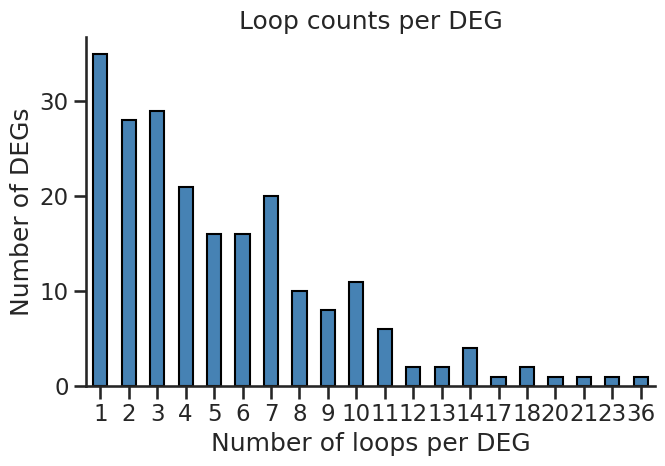

In [28]:
import matplotlib.pyplot as plt

# Count number of loops per DEG
loops_per_deg = loops_with_entrezid.groupby("gene_symbol")["Unnamed: 0"].nunique().reset_index()
loops_per_deg.columns = ["gene", "loop_count"]

# Plot distribution
plt.figure(figsize=(7,5))
loops_per_deg["loop_count"].value_counts().sort_index().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.xlabel("Number of loops per DEG")
plt.ylabel("Number of DEGs")
plt.title("Loop counts per DEG")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

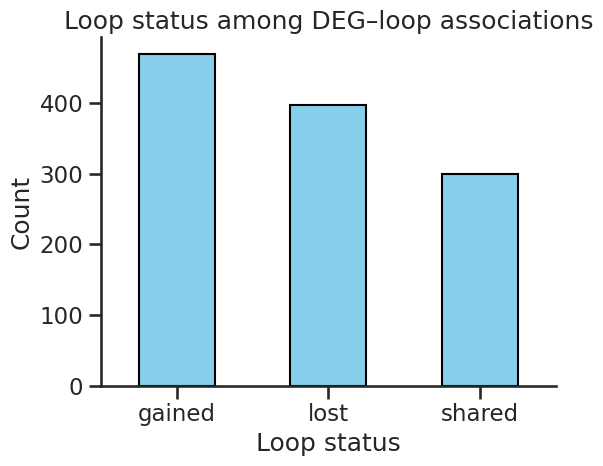

In [26]:
plt.figure(figsize=(6,5))
loops_with_entrezid["status"].value_counts().plot(
    kind="bar", color="skyblue", edgecolor="black"
)
plt.xlabel("Loop status")
plt.ylabel("Count")
plt.title("Loop status among DEG–loop associations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

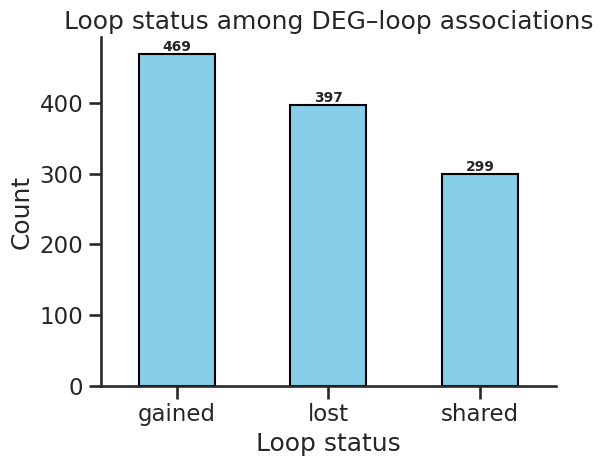

In [27]:
plt.figure(figsize=(6,5))
ax = loops_with_entrezid["status"].value_counts().plot(
    kind="bar", color="skyblue", edgecolor="black"
)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, weight='bold'
    )

plt.xlabel("Loop status")
plt.ylabel("Count")
plt.title("Loop status among DEG–loop associations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
